# Student Performance Prediction using a Cascaded Machine Learning Pipeline

### ACM SIGAI Final Project

**Team:** Your Team Name

**Dataset:** UCI Student Performance Dataset (student-mat.csv)

---

## Objective

The objective of this project is to build a cascaded machine learning pipeline for predicting student academic performance.

Instead of relying on a single model, three machine learning models are connected in sequence.

- Stage 1 predicts whether a student will pass or fail.
- Stage 2 predicts the student's final grade.
- Stage 3 classifies the student's overall performance into Poor, Average, Good, or Excellent.

This approach provides both detailed predictions and interpretable outcomes for educational decision-making.

## Pipeline Design

Stage 1 → Predict Pass/Fail

↓

Pass Probability

↓

Stage 2 → Predict Final Grade

↓

Predicted Grade

↓

Stage 3 → Predict Performance Category

↓

Poor / Average / Good / Excellent

## Block 1 — Import Libraries

This section imports all required Python libraries for data handling, visualization, preprocessing, model training, evaluation, and building the cascaded machine learning pipeline.

In [7]:
# ============================================================
# FINAL PROJECT — Student Performance Prediction
# Cascaded ML Pipeline
# ACM SIGAI ML Recruitment | Week 3
# ============================================================

# ── IMPORTS ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             mean_absolute_error, r2_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')
print("✅ All imports done")


✅ All imports done


## Block 2 — Load Dataset

The Student Performance dataset is loaded into a Pandas DataFrame.

The dataset contains demographic, social, and academic information for Portuguese secondary school students.

The target variable used throughout this project is the final grade (G3).

In [8]:
# ── LOAD DATA ─────────────────────────────────────────────
# The original URL was returning a 404 error, but the file 'student-mat.csv' is available locally.
df = pd.read_csv('student-mat.csv', sep=';')
print("\n📊 Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nMissing values:", df.isnull().sum().sum())


📊 Dataset Shape: (395, 33)

First 5 rows:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

Columns: ['school', 'sex', 'age', 'address',

## Block 3 — Dataset Exploration

The structure of the dataset is examined by checking the number of rows, columns, data types, missing values, and summary statistics.

Understanding the dataset helps identify preprocessing requirements before model development.

## Block 4 — Exploratory Data Analysis

EDA is performed to understand feature distributions and relationships between variables.

Visualizations such as histograms, correlation heatmaps, count plots, and scatter plots help identify useful patterns in the data.


📊 Target variable (G3 - Final Grade) stats:
count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


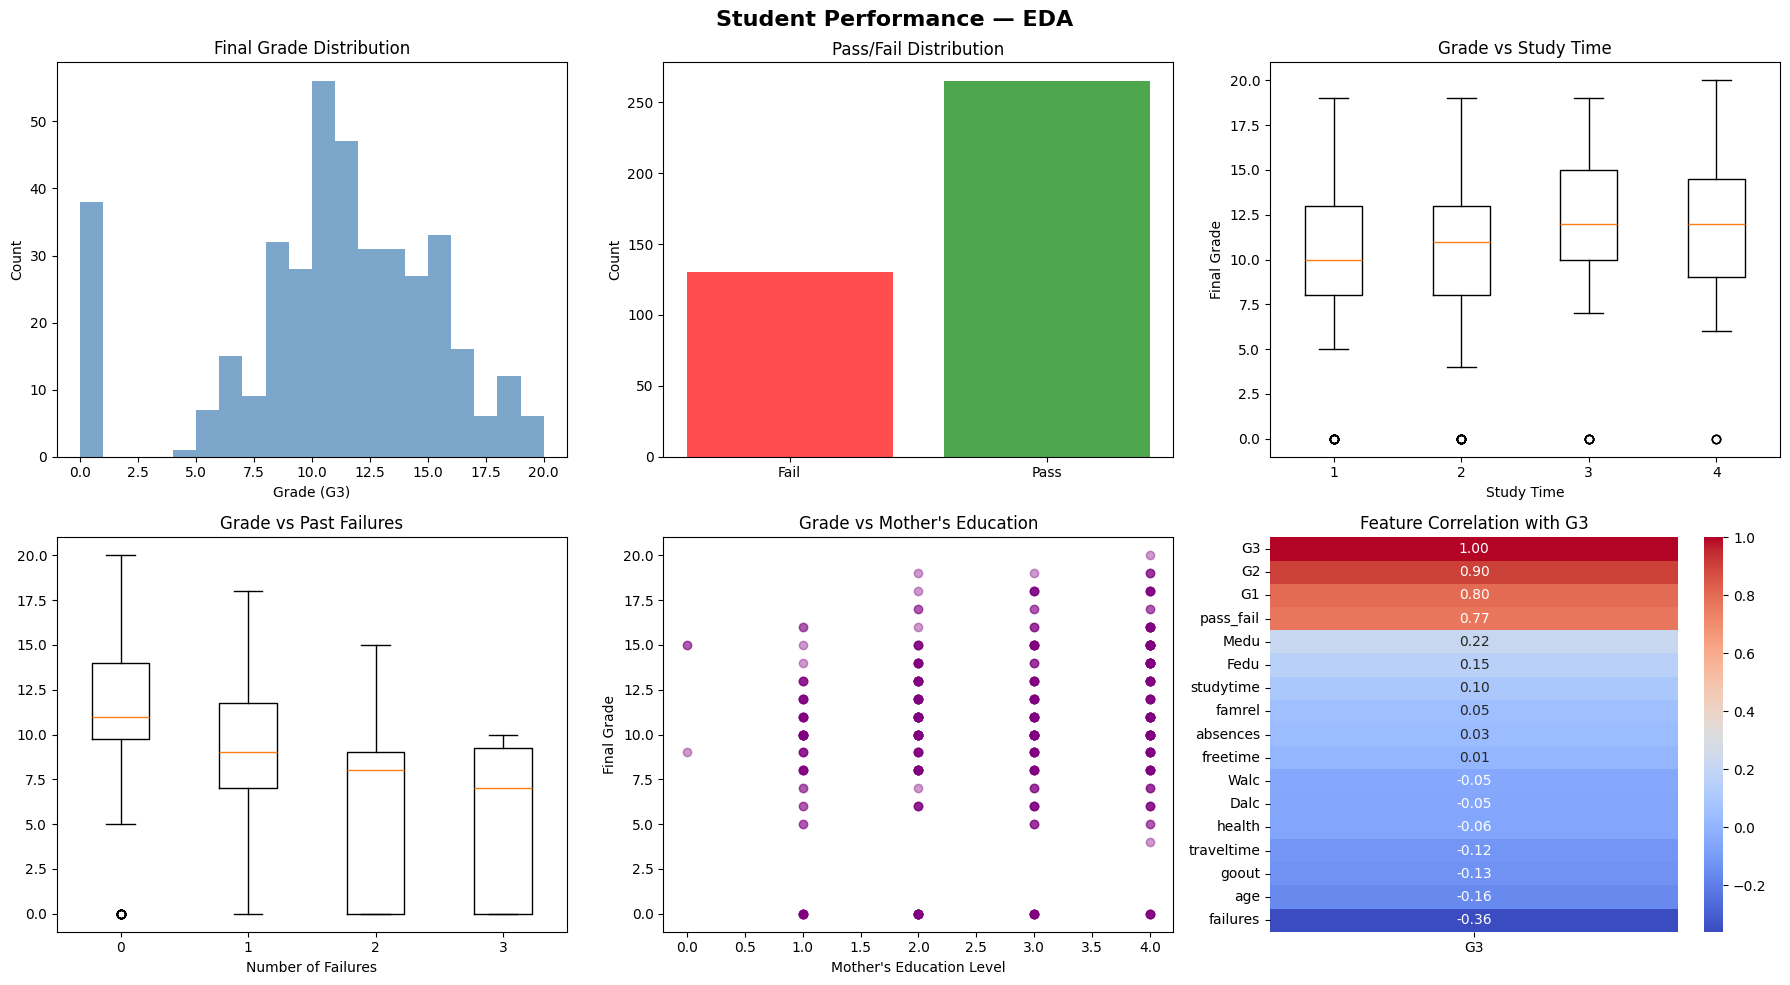

In [9]:
# ── EDA ───────────────────────────────────────────────────
print("\n📊 Target variable (G3 - Final Grade) stats:")
print(df['G3'].describe())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Grade distribution
axes[0,0].hist(df['G3'], bins=20, color='steelblue', alpha=0.7)
axes[0,0].set_title('Final Grade Distribution')
axes[0,0].set_xlabel('Grade (G3)')
axes[0,0].set_ylabel('Count')

# Pass/Fail distribution
df['pass_fail'] = (df['G3'] >= 10).astype(int)
axes[0,1].bar(['Fail', 'Pass'],
               df['pass_fail'].value_counts().sort_index().values,
               color=['red', 'green'], alpha=0.7)
axes[0,1].set_title('Pass/Fail Distribution')
axes[0,1].set_ylabel('Count')

# Grade vs Study Time
axes[0,2].boxplot([df[df['studytime']==i]['G3'].values
                   for i in sorted(df['studytime'].unique())],
                   labels=sorted(df['studytime'].unique()))
axes[0,2].set_title('Grade vs Study Time')
axes[0,2].set_xlabel('Study Time')
axes[0,2].set_ylabel('Final Grade')

# Grade vs Failures
axes[1,0].boxplot([df[df['failures']==i]['G3'].values
                   for i in sorted(df['failures'].unique())],
                   labels=sorted(df['failures'].unique()))
axes[1,0].set_title('Grade vs Past Failures')
axes[1,0].set_xlabel('Number of Failures')

# Grade vs Parents Education
axes[1,1].scatter(df['Medu'], df['G3'], alpha=0.4, color='purple')
axes[1,1].set_title("Grade vs Mother's Education")
axes[1,1].set_xlabel("Mother's Education Level")
axes[1,1].set_ylabel('Final Grade')

# Correlation heatmap — numeric only
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr()[['G3']].sort_values('G3', ascending=False),
            annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Feature Correlation with G3')

plt.suptitle('Student Performance — EDA', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Block 5 — Feature Engineering

New features are created from existing attributes to improve predictive performance.

Examples include total parental education, overall support score, attendance indicators, and academic progress features.

In [10]:
# ── FEATURE ENGINEERING ───────────────────────────────────
# 1. Parent education average
df['parent_edu_avg'] = (df['Medu'] + df['Fedu']) / 2

# 2. Total alcohol consumption
df['total_alcohol'] = df['Dalc'] + df['Walc']

# 3. Support score — how much support does student get
df['support_score'] = (
    (df['schoolsup'] == 'yes').astype(int) +
    (df['famsup'] == 'yes').astype(int) +
    (df['paid'] == 'yes').astype(int) +
    (df['activities'] == 'yes').astype(int)
)

# 4. Grade trend (G1 → G2 improvement)
df['grade_trend'] = df['G2'] - df['G1']

# 5. Previous grade average
df['prev_grade_avg'] = (df['G1'] + df['G2']) / 2

print("✅ Features engineered:")
print("1. parent_edu_avg — average of both parents education")
print("2. total_alcohol — combined weekday + weekend alcohol")
print("3. support_score — total support resources available")
print("4. grade_trend — improvement from G1 to G2")
print("5. prev_grade_avg — average of first two grades")

✅ Features engineered:
1. parent_edu_avg — average of both parents education
2. total_alcohol — combined weekday + weekend alcohol
3. support_score — total support resources available
4. grade_trend — improvement from G1 to G2
5. prev_grade_avg — average of first two grades


## Block 6 — Data Preprocessing

Categorical variables are encoded into numerical form.

The dataset is split into training and testing sets, and numerical features are standardized wherever required.

In [22]:
# ── PREPARE DATA ──────────────────────────────────────────
# Drop original grade columns to prevent leakage in Stage 1
# Keep G1, G2 as they're legitimate predictors
X = df.drop(['G3', 'pass_fail', 'performance'], axis=1, errors='ignore')
y_classification = df['pass_fail']    # Stage 1 target
y_regression = df['G3']               # Stage 2 target

# Performance categories for Stage 3
def grade_category(g):
    if g < 10: return 'Poor'
    elif g < 13: return 'Average'
    elif g < 16: return 'Good'
    else: return 'Excellent'

df['performance'] = df['G3'].apply(grade_category)

# ── FIX: Encode string categories into integers for XGBoost ──
label_encoder = LabelEncoder()
y_multiclass = label_encoder.fit_transform(df['performance'])

# Create target labels for Stage 3
# ─────────────────────────────────────────────────────────────

print("\n📊 Stage targets:")
print("Stage 1 — Pass/Fail:", y_classification.value_counts().to_dict())
print("Stage 2 — Grade (G3): mean =", y_regression.mean().round(2))
print("Stage 3 — Performance (Encoded):", dict(zip(label_encoder.classes_, np.bincount(y_multiclass))))

# Identify column types
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("\nNumeric features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))

# Split data
X_train, X_test, y1_train, y1_test = train_test_split(
    X, y_classification, test_size=0.2, random_state=42, stratify=y_classification)

_, _, y2_train, y2_test = train_test_split(
    X, y_regression, test_size=0.2, random_state=42)

_, _, y3_train, y3_test = train_test_split(
    X, y_multiclass, test_size=0.2, random_state=42, stratify=y_multiclass)

print("\n✅ Data split done")
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# Build preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('scaler', StandardScaler())]), numeric_cols),
    ('cat', Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)])



📊 Stage targets:
Stage 1 — Pass/Fail: {1: 265, 0: 130}
Stage 2 — Grade (G3): mean = 10.42
Stage 3 — Performance (Encoded): {'Average': np.int64(134), 'Excellent': np.int64(40), 'Good': np.int64(91), 'Poor': np.int64(130)}

Numeric features: 20
Categorical features: 17

✅ Data split done
Train size: 316
Test size: 79


## Block 7 — Stage 1 : Pass / Fail Classification

The first stage predicts whether a student will pass or fail.

The predicted probability of passing is forwarded to the next stage as an additional feature, making this the first component of the cascaded pipeline.


STAGE 1 — Pass/Fail Classification
Accuracy: 0.8734
F1 Score: 0.9000
ROC-AUC:  0.9427

Predicted PASS: 47
Predicted FAIL: 32


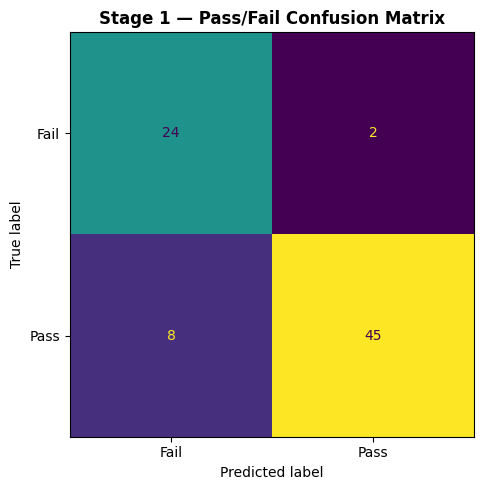

In [14]:
# ── STAGE 1: PASS/FAIL CLASSIFIER ────────────────────────
print("\n" + "="*60)
print("STAGE 1 — Pass/Fail Classification")
print("="*60)

stage1_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100, random_state=42,
        eval_metric='logloss', verbosity=0))])

stage1_pipeline.fit(X_train, y1_train)
y1_pred = stage1_pipeline.predict(X_test)
y1_prob = stage1_pipeline.predict_proba(X_test)[:, 1]

s1_accuracy = accuracy_score(y1_test, y1_pred)
s1_f1 = f1_score(y1_test, y1_pred)
s1_auc = roc_auc_score(y1_test, y1_prob)

print(f"Accuracy: {s1_accuracy:.4f}")
print(f"F1 Score: {s1_f1:.4f}")
print(f"ROC-AUC:  {s1_auc:.4f}")
print(f"\nPredicted PASS: {(y1_pred==1).sum()}")
print(f"Predicted FAIL: {(y1_pred==0).sum()}")

# Confusion matrix Stage 1
fig, ax = plt.subplots(figsize=(6, 5))
cm1 = confusion_matrix(y1_test, y1_pred)
ConfusionMatrixDisplay(cm1,
    display_labels=['Fail','Pass']).plot(ax=ax, colorbar=False)
ax.set_title('Stage 1 — Pass/Fail Confusion Matrix',
             fontweight='bold')
plt.tight_layout()
plt.show()

## Block 8 — Evaluation of Stage 1

The classification model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

These metrics indicate how well the model identifies students who are likely to pass or fail.

The Stage 1 classifier is evaluated using Accuracy, F1-score, ROC-AUC, and a Confusion Matrix.

These metrics indicate how effectively the model distinguishes between students who pass and those who fail.

## Block 9 — Stage 2 : Final Grade Prediction

The second stage predicts the student's final grade (G3).

The probability generated by Stage 1 is used as an additional feature, allowing the regression model to leverage information from the previous stage.


STAGE 2 — Grade Score Prediction (Regression)
MAE: 3.6262
R²:  -0.0120

Mean predicted grade: 10.60
Mean actual grade:    10.77


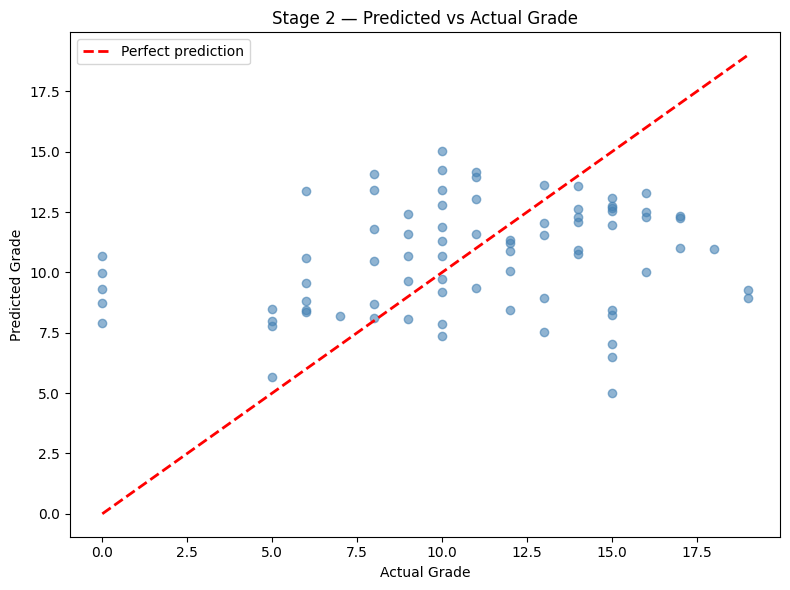

In [15]:
# ── STAGE 2: GRADE REGRESSION ────────────────────────────
print("\n" + "="*60)
print("STAGE 2 — Grade Score Prediction (Regression)")
print("="*60)

# Add Stage 1 probability as a feature for Stage 2
X_train_s2 = X_train.copy()
X_train_s2['pass_probability'] = stage1_pipeline.predict_proba(X_train)[:, 1]

X_test_s2 = X_test.copy()
X_test_s2['pass_probability'] = y1_prob  # Stage 1 output → Stage 2 input!

# Update numeric cols to include new feature
numeric_cols_s2 = numeric_cols + ['pass_probability']

preprocessor_s2 = ColumnTransformer(transformers=[
    ('num', Pipeline([('scaler', StandardScaler())]), numeric_cols_s2),
    ('cat', Pipeline([('encoder', OneHotEncoder(
        handle_unknown='ignore'))]), categorical_cols)])

stage2_pipeline = Pipeline([
    ('preprocessor', preprocessor_s2),
    ('regressor', XGBRegressor(
        n_estimators=100, random_state=42, verbosity=0))])

stage2_pipeline.fit(X_train_s2, y2_train)
y2_pred = stage2_pipeline.predict(X_test_s2)

s2_mae = mean_absolute_error(y2_test, y2_pred)
s2_r2 = r2_score(y2_test, y2_pred)

print(f"MAE: {s2_mae:.4f}")
print(f"R²:  {s2_r2:.4f}")
print(f"\nMean predicted grade: {y2_pred.mean():.2f}")
print(f"Mean actual grade:    {y2_test.mean():.2f}")

# Predicted vs Actual plot
plt.figure(figsize=(8, 6))
plt.scatter(y2_test, y2_pred, alpha=0.6, color='steelblue')
plt.plot([y2_test.min(), y2_test.max()],
         [y2_test.min(), y2_test.max()],
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Grade')
plt.ylabel('Predicted Grade')
plt.title('Stage 2 — Predicted vs Actual Grade')
plt.legend()
plt.tight_layout()
plt.show()

## Block 10 — Evaluation of Stage 2

Regression performance is measured using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics evaluate the accuracy of predicted grades.

## Block 11 — Stage 3 : Performance Category Classification

The predicted grade from Stage 2 is converted into a performance category.

The possible categories are:

- Poor
- Average
- Good
- Excellent

This stage provides an interpretable summary of student performance.


STAGE 3 — Performance Category Classification
Accuracy: 0.5443
F1 Macro: 0.4063

Detailed Report:
              precision    recall  f1-score   support

     Average       0.72      0.96      0.83        27
   Excellent       0.00      0.00      0.00         8
        Good       0.42      0.44      0.43        18
        Poor       0.39      0.35      0.37        26

    accuracy                           0.54        79
   macro avg       0.38      0.44      0.41        79
weighted avg       0.47      0.54      0.50        79



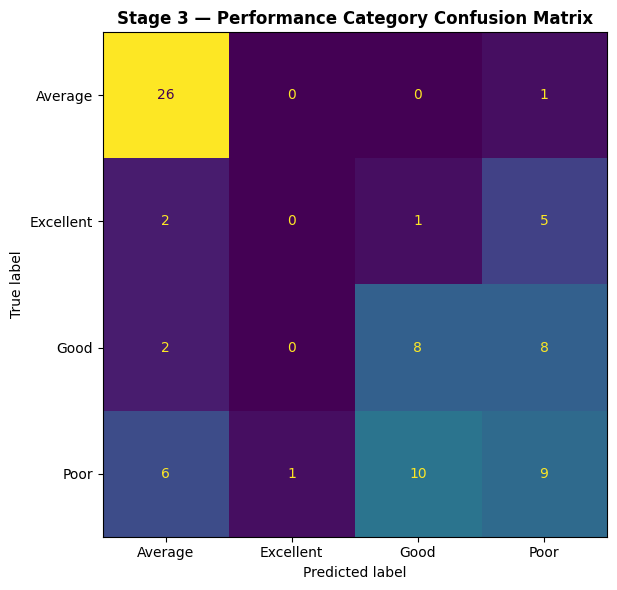

In [17]:
# ── STAGE 3: PERFORMANCE CATEGORY ────────────────────────
print("\n" + "="*60)
print("STAGE 3 — Performance Category Classification")
print("=========="*60)

# Stage 2 prediction → Stage 3 input!
X_train_s3 = X_train_s2.copy()
X_train_s3['predicted_grade'] = stage2_pipeline.predict(X_train_s2)

X_test_s3 = X_test_s2.copy()
X_test_s3['predicted_grade'] = y2_pred   # Stage 2 output → Stage 3 input!

numeric_cols_s3 = numeric_cols_s2 + ['predicted_grade']

preprocessor_s3 = ColumnTransformer(transformers=[
    ('num', Pipeline([('scaler', StandardScaler())]), numeric_cols_s3),
    ('cat', Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)])

stage3_pipeline = Pipeline([
    ('preprocessor', preprocessor_s3),
    ('classifier', XGBClassifier(
        n_estimators=100, random_state=42,
        eval_metric='mlogloss', verbosity=0))])

stage3_pipeline.fit(X_train_s3, y3_train)
y3_pred = stage3_pipeline.predict(X_test_s3)

s3_accuracy = accuracy_score(y3_test, y3_pred)
s3_f1 = f1_score(y3_test, y3_pred, average='macro')

print(f"Accuracy: {s3_accuracy:.4f}")
print(f"F1 Macro: {s3_f1:.4f}")

print("\nDetailed Report:")
# FIX: Map text targets onto classification report
print(classification_report(y3_test, y3_pred, target_names=label_encoder.classes_))

# Confusion matrix Stage 3
fig, ax = plt.subplots(figsize=(8, 6))
categories = label_encoder.classes_
cm3 = confusion_matrix(y3_test, y3_pred)

# FIX: Plot matrix mapping back to the proper string classes
ConfusionMatrixDisplay(cm3, display_labels=categories).plot(ax=ax, colorbar=False)
ax.set_title('Stage 3 — Performance Category Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()


## Block 12 – Evaluation of Stage 3

The Stage 3 model is evaluated using Accuracy, F1-score, and a Confusion Matrix.

This stage classifies students into Poor, Average, Good, or Excellent based on the predicted grade from Stage 2.

## Block 13 – End-to-End Pipeline Summary

This section summarizes the performance of all three stages in the cascaded machine learning pipeline and presents the final outputs together.

In [18]:
# ── END TO END SUMMARY ────────────────────────────────────
print("\n" + "="*60)
print("END-TO-END CASCADE SUMMARY")
print("="*60)
print(f"""
🔗 PIPELINE ARCHITECTURE:

ALL STUDENTS ({len(X_test)} in test set)
        ↓
[Stage 1: Pass/Fail Classifier — XGBoost]
  → Accuracy: {s1_accuracy:.3f} | F1: {s1_f1:.3f} | AUC: {s1_auc:.3f}
        ↓
[Stage 2: Grade Score Regressor — XGBoost]
  → Uses Stage 1 pass_probability as extra feature
  → MAE: {s2_mae:.3f} | R²: {s2_r2:.3f}
        ↓
[Stage 3: Performance Category Classifier — XGBoost]
  → Uses Stage 2 predicted_grade as extra feature
  → Accuracy: {s3_accuracy:.3f} | F1 Macro: {s3_f1:.3f}

✅ WHY 3 MODELS:
  Stage 1 → Binary Classification (Pass/Fail)
  Stage 2 → Regression (Exact grade score)
  Stage 3 → Multi-class Classification (Poor/Average/Good/Excellent)
  Each is a different problem type — one model cannot do all three!

📊 HOW OUTPUTS FLOW:
  Stage 1 output (pass_probability) → becomes feature in Stage 2
  Stage 2 output (predicted_grade)  → becomes feature in Stage 3
""")




END-TO-END CASCADE SUMMARY

🔗 PIPELINE ARCHITECTURE:

ALL STUDENTS (79 in test set)
        ↓
[Stage 1: Pass/Fail Classifier — XGBoost]
  → Accuracy: 0.873 | F1: 0.900 | AUC: 0.943
        ↓
[Stage 2: Grade Score Regressor — XGBoost]
  → Uses Stage 1 pass_probability as extra feature
  → MAE: 3.626 | R²: -0.012
        ↓
[Stage 3: Performance Category Classifier — XGBoost]
  → Uses Stage 2 predicted_grade as extra feature
  → Accuracy: 0.544 | F1 Macro: 0.406

✅ WHY 3 MODELS:
  Stage 1 → Binary Classification (Pass/Fail)
  Stage 2 → Regression (Exact grade score)
  Stage 3 → Multi-class Classification (Poor/Average/Good/Excellent)
  Each is a different problem type — one model cannot do all three!

📊 HOW OUTPUTS FLOW:
  Stage 1 output (pass_probability) → becomes feature in Stage 2
  Stage 2 output (predicted_grade)  → becomes feature in Stage 3



## Block 13 — Cascaded Pipeline Architecture

The following diagram illustrates how information flows through the complete cascaded machine learning pipeline.

Each model receives the output of the previous model, forming an end-to-end decision-making system.

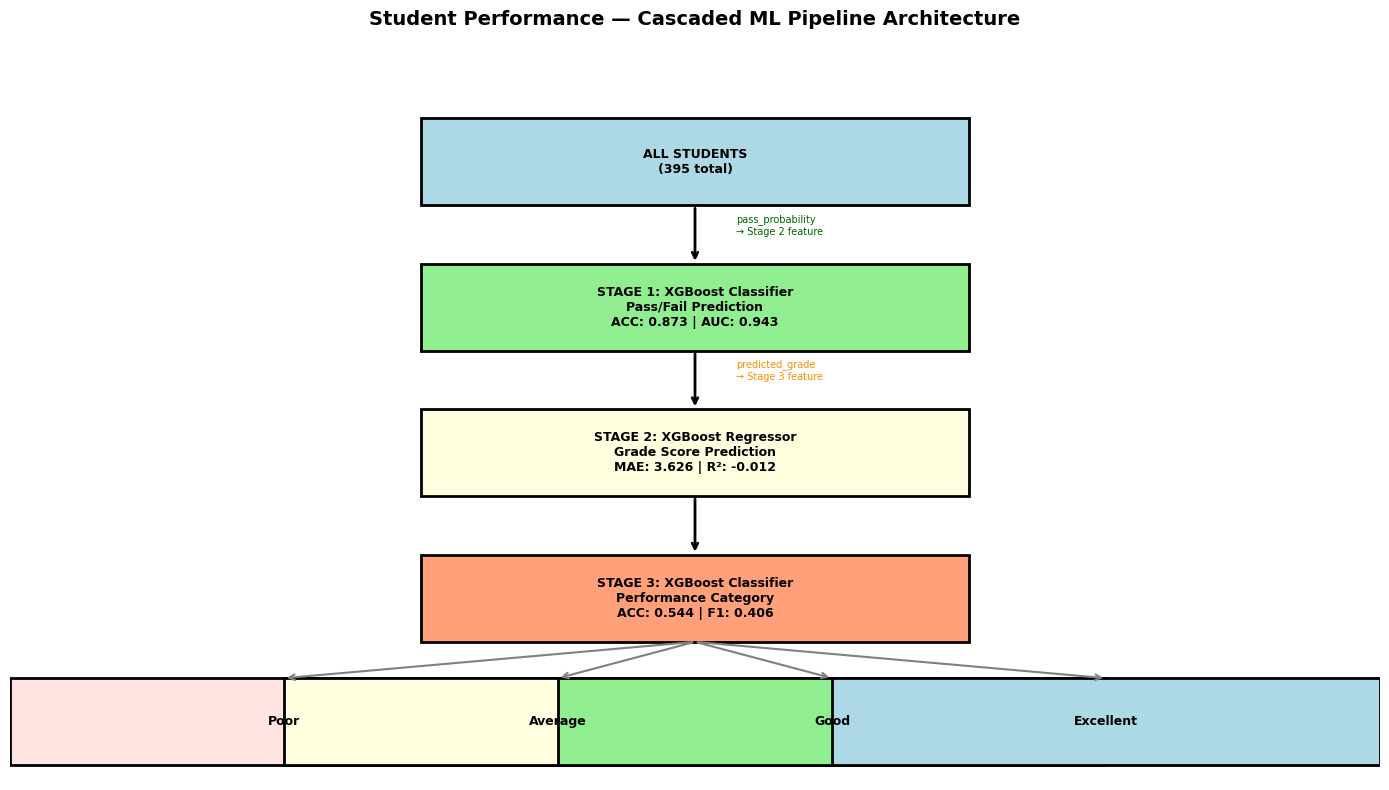


🎉 Final Project Complete!
Upload this notebook to GitHub under Week3_Deep_Learning/Final_Project/


In [19]:
# ── ARCHITECTURE DIAGRAM ──────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Boxes
boxes = [
    (5, 8.5, 'ALL STUDENTS\n(395 total)', 'lightblue'),
    (5, 6.5, 'STAGE 1: XGBoost Classifier\nPass/Fail Prediction\nACC: {:.3f} | AUC: {:.3f}'.format(s1_accuracy, s1_auc), 'lightgreen'),
    (5, 4.5, 'STAGE 2: XGBoost Regressor\nGrade Score Prediction\nMAE: {:.3f} | R²: {:.3f}'.format(s2_mae, s2_r2), 'lightyellow'),
    (5, 2.5, 'STAGE 3: XGBoost Classifier\nPerformance Category\nACC: {:.3f} | F1: {:.3f}'.format(s3_accuracy, s3_f1), 'lightsalmon'),
    (2, 0.8, 'Poor', 'mistyrose'),
    (4, 0.8, 'Average', 'lightyellow'),
    (6, 0.8, 'Good', 'lightgreen'),
    (8, 0.8, 'Excellent', 'lightblue'),
]

for x, y, text, color in boxes:
    ax.add_patch(plt.Rectangle((x-2, y-0.6), 4, 1.2,
                                facecolor=color, edgecolor='black',
                                linewidth=2, zorder=2))
    ax.text(x, y, text, ha='center', va='center',
            fontsize=9, fontweight='bold', zorder=3)

# Arrows
for y_start, y_end in [(7.9, 7.1), (5.9, 5.1), (3.9, 3.1)]:
    ax.annotate('', xy=(5, y_end), xytext=(5, y_start),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Stage 3 to outputs
for x_end in [2, 4, 6, 8]:
    ax.annotate('', xy=(x_end, 1.4), xytext=(5, 1.9),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Labels on arrows
ax.text(5.3, 7.5, 'pass_probability\n→ Stage 2 feature',
        fontsize=7, color='darkgreen')
ax.text(5.3, 5.5, 'predicted_grade\n→ Stage 3 feature',
        fontsize=7, color='darkorange')

ax.set_title('Student Performance — Cascaded ML Pipeline Architecture',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n🎉 Final Project Complete!")
print("Upload this notebook to GitHub under Week3_Deep_Learning/Final_Project/")

## Block 14 — Conclusion

A three-stage cascaded machine learning pipeline was successfully developed for predicting student academic performance.

Unlike a single-model approach, the cascade combines multiple predictive stages to provide detailed and interpretable results.

Future work may include larger educational datasets, deep learning models, and real-time student monitoring systems.